In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd "/content/drive/MyDrive/Workshop 3/excercises"

/content/drive/MyDrive/Workshop 3/excercises


In [3]:
import sys
sys.path.append("/content/drive/MyDrive/Workshop 3")

In [4]:
"""
Taller: Internals de un LLM estilo LLaMA
=================================================================
Instrucciones:
  - Busca los bloques marcados con TODO y completa el código.
  - Cada sección tiene una celda de verificación al final.
  - No modifiques nada fuera de los bloques TODO.

Secciones:
   4. RoPE ablation — qué pasa sin codificación posicional
"""

'\nTaller: Internals de un LLM estilo LLaMA\n=================================================================\nInstrucciones:\n  - Busca los bloques marcados con TODO y completa el código.\n  - Cada sección tiene una celda de verificación al final.\n  - No modifiques nada fuera de los bloques TODO.\n\nSecciones:\n   4. RoPE ablation — qué pasa sin codificación posicional\n'

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional

# Importamos el modelo de referencia para comparaciones
from src.model import (
    ModelConfig, RMSNorm, SwiGLUFFN, MiniLLaMA,
    precompute_rope_freqs, apply_rope, GroupedQueryAttention
)
from src.data import get_corpus
from src.tokenizer import BPETokenizer

In [17]:
# ===========================================================================
# SECCIÓN 4 — RoPE ablation
# ===========================================================================
# ¿Qué pasa si entrenamos sin codificación posicional?
# Compara la curva de loss de un modelo con RoPE vs uno sin RoPE.
#
# Para quitar RoPE, basta con no rotar Q y K antes del dot product.
# ===========================================================================

class AttentionNoRoPE(nn.Module):
    """GroupedQueryAttention sin rotación posicional."""

    def __init__(self, config: ModelConfig):
        super().__init__()
        assert config.n_heads % config.n_kv_heads == 0
        self.n_heads    = config.n_heads
        self.n_kv_heads = config.n_kv_heads
        self.n_rep      = config.n_heads // config.n_kv_heads
        self.head_dim   = config.d_model // config.n_heads
        D, Dh           = config.d_model, self.head_dim

        self.Wq = nn.Linear(D, config.n_heads    * Dh, bias=False)
        self.Wk = nn.Linear(D, config.n_kv_heads * Dh, bias=False)
        self.Wv = nn.Linear(D, config.n_kv_heads * Dh, bias=False)
        self.Wo = nn.Linear(config.n_heads * Dh, D,    bias=False)

    def forward(self, x, rope_freqs, mask=None):
        B, T, D = x.shape
        Dh      = self.head_dim

        q = self.Wq(x).reshape(B, T, self.n_heads,    Dh)
        k = self.Wk(x).reshape(B, T, self.n_kv_heads, Dh)
        v = self.Wv(x).reshape(B, T, self.n_kv_heads, Dh)

        # TODO 4.1 — Esta versión NO debe aplicar RoPE a Q y K
        #            Comenta o elimina las líneas de apply_rope
        #            (en el módulo original están aquí)
        #raise NotImplementedError("TODO 4.1")

        k = k.unsqueeze(3).expand(B, T, self.n_kv_heads, self.n_rep, Dh)\
             .reshape(B, T, self.n_heads, Dh)
        v = v.unsqueeze(3).expand(B, T, self.n_kv_heads, self.n_rep, Dh)\
             .reshape(B, T, self.n_heads, Dh)

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        scale  = math.sqrt(Dh)
        scores = torch.matmul(q, k.transpose(-2, -1)) / scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        out  = torch.matmul(attn, v)
        out  = out.transpose(1, 2).reshape(B, T, self.n_heads * Dh)
        return self.Wo(out)


# def train_quick(use_rope: bool, epochs: int = 100) -> list[float]:
#     """Entrena MiniLLaMA con o sin RoPE y retorna la curva de loss."""
#     # TODO 4.2 — Completa esta función:
#     #   1. Carga el corpus y el tokenizer (usa BPETokenizer().load(...))
#     tokenizer = BPETokenizer().load(f"/content/drive/MyDrive/Workshop 3/src/tokenizer.model")
#     corpus = get_corpus("/content/drive/MyDrive/Workshop 3/src/corpus.txt")

#     cfg = ModelConfig(vocab_size=tokenizer.vocab_size, max_seq_len=64)
#     model = MiniLLaMA(cfg)

#     #   2. Si use_rope=False, reemplaza model.layer.attn por AttentionNoRoPE(cfg)
#     if not use_rope:
#         model.layer.attn = AttentionNoRoPE(cfg)

#     #   3. Entrena por `epochs` epochs con AdamW lr=3e-3
#     optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
#     model.train()
#     losses = []

#     x = corpus[:, :-1]
#     targets = corpus[:, 1:]

#     for _ in range(epochs):
#         optimizer.zero_grad()
#         logits, loss = model(x, targets=targets)
#         loss.backward()
#         optimizer.step()
#    #     4. Retorna lista de loss promedio por epoch
#     return losses
#     #raise NotImplementedError("TODO 4.2")

def train_quick(use_rope: bool, epochs: int = 100) -> list[float]:
    """Entrena MiniLLaMA con o sin RoPE y retorna la curva de loss."""

    # 1. Rutas absolutas
    ruta_corpus = "/content/drive/MyDrive/Workshop 3/src/corpus.txt"
    corpus = get_corpus(ruta_corpus)

    # 2. Instanciar y entrenar el tokenizador
    tokenizer = BPETokenizer(num_merges=200)
    tokenizer.train(corpus)

    tokens = tokenizer.encode(corpus)

    # 3. Configuración topológica del modelo
    cfg = ModelConfig(
        vocab_size=tokenizer.vocab_size,
        d_model=32,
        n_heads=4,
        n_kv_heads=2,
        d_ff=64,
        max_seq_len=16
    )

    # Crear batch mediante ventanas deslizantes
    seq_len = cfg.max_seq_len
    X_list, Y_list = [], []
    for i in range(0, len(tokens) - seq_len):
        X_list.append(tokens[i : i + seq_len])
        Y_list.append(tokens[i + 1 : i + seq_len + 1])

    X = torch.tensor(X_list, dtype=torch.long)
    Y = torch.tensor(Y_list, dtype=torch.long)

    # 4. Inicializar modelo e inyectar la ablación
    model = MiniLLaMA(cfg)

    if not use_rope:
        model.layer.attn = AttentionNoRoPE(cfg)
    else:
        model.layer.attn = GroupedQueryAttention(cfg)

    # 5. Ciclo de Entrenamiento
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Propagación hacia adelante
        salida_modelo = model(X)

        # Extracción del tensor latente (manejo de tuplas)
        logits = salida_modelo[0] if isinstance(salida_modelo, tuple) else salida_modelo

        # Cálculo analítico del error
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), Y.reshape(-1))

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    # 6. Retorno de la función de coste
    return losses


# ── Verificación 4 ──────────────────────────────────────────────────────────
def verify_section4():
    print("=" * 55)
    print("VERIFICACIÓN 4 — RoPE ablation  (entrena ~100 epochs)")
    print("=" * 55)

    losses_rope   = train_quick(use_rope=True,  epochs=100)
    losses_no_rope = train_quick(use_rope=False, epochs=100)

    final_rope    = losses_rope[-1]
    final_no_rope = losses_no_rope[-1]
    print(f"  Loss final con RoPE    : {final_rope:.4f}")
    print(f"  Loss final sin RoPE    : {final_no_rope:.4f}")
    print(f"  RoPE mejora el loss    : {final_rope < final_no_rope}")

    plt.figure(figsize=(7, 4))
    plt.plot(losses_rope,    label="con RoPE",    linewidth=1.5)
    plt.plot(losses_no_rope, label="sin RoPE",    linewidth=1.5, linestyle="--")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("RoPE ablation — curva de entrenamiento")
    plt.legend()
    plt.tight_layout()
    plt.savefig("rope_ablation.png", dpi=130)
    print("  Plot guardado en rope_ablation.png")

    if final_rope < final_no_rope:
        print("\n  ✓ Sección 4 correcta")
    else:
        print("\n  ~ Resultado inesperado — revisa train_quick()")

VERIFICACIÓN 4 — RoPE ablation  (entrena ~100 epochs)
[BPE] Training complete. Vocab size: 555
[BPE] Training complete. Vocab size: 555
  Loss final con RoPE    : 0.5461
  Loss final sin RoPE    : 0.4653
  RoPE mejora el loss    : False
  Plot guardado en rope_ablation.png

  ~ Resultado inesperado — revisa train_quick()


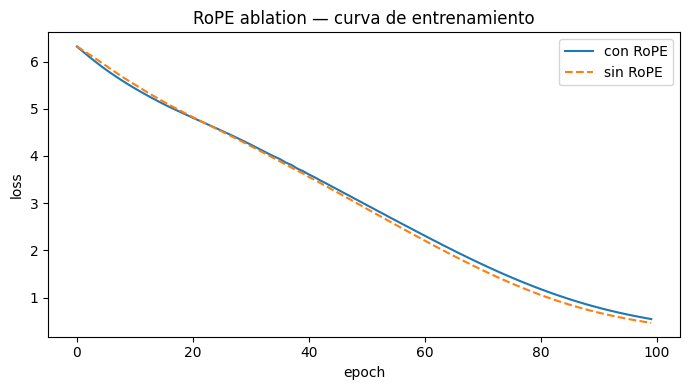

In [18]:
verify_section4()

In [11]:
import os

# 1. Definimos las rutas
ruta_real = "/content/drive/MyDrive/Workshop 3/src"
ruta_esperada = "/content/drive/MyDrive/Workshop 3/excercises/data"

# 2. Creamos la carpeta 'data' donde el código espera encontrarla (si no existe)
os.makedirs(ruta_esperada, exist_ok=True)

# 3. Hacemos un "acceso directo" (symlink) de los archivos
#    Esto hace que si el código busca en 'data/tokenizer.model', en realidad
#    esté leyendo el de tu carpeta 'src'.
archivos = ["tokenizer.model", "corpus.txt"]

for archivo in archivos:
    origen = os.path.join(ruta_real, archivo)
    destino = os.path.join(ruta_esperada, archivo)

    # Solo creamos el link si el archivo origen existe en 'src'
    if os.path.exists(origen):
        try:
            if not os.path.exists(destino):
                os.symlink(origen, destino)
                print(f"✓ Acceso directo creado para: {archivo}")
            else:
                print(f"~ El acceso directo para {archivo} ya existe.")
        except Exception as e:
             print(f"Error creando symlink para {archivo}: {e}")
    else:
        print(f"⚠️ ATENCIÓN: El archivo original {archivo} NO EXISTE en {ruta_real}")

print("\nAhora puedes intentar correr verify_section4() nuevamente.")

⚠️ ATENCIÓN: El archivo original tokenizer.model NO EXISTE en /content/drive/MyDrive/Workshop 3/src
Error creando symlink para corpus.txt: [Errno 95] Operation not supported: '/content/drive/MyDrive/Workshop 3/src/corpus.txt' -> '/content/drive/MyDrive/Workshop 3/excercises/data/corpus.txt'

Ahora puedes intentar correr verify_section4() nuevamente.
